## Retail Data Analysis

**Tasks**

- Check for missing values
- Check for duplicate values
- Validate data quality

In [0]:
# Setting up the Path

# Set the storage account key in spark config
spark.conf.set(
    "fs.azure.account.key.retailsalesresources.blob.core.windows.net",
    dbutils.secrets.get("databricksScope", "storageaccount-secrets")  
)

# File path for raw-data container
RAW_DATA_PATH = "wasbs://raw-data@retailsalesresources.blob.core.windows.net"

try:
    # Loading the CSV files
    retail_data = (
        spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .csv(f"{RAW_DATA_PATH}/retail_data.csv")
    )

    # Saving the CSV files as a pandas dataframe
    df = retail_data.toPandas()
except Exception as e:
    raise Exception("Couldn't load the CSV file")


In [0]:
## Total row counts
print("Total rows are: ",retail_data.count())


print("\n","=" *40)
print("Product details schema:")
retail_data.printSchema()


print("\n","=" *40)
print("Total number of columns\n",len(retail_data.columns))

Total rows are:  4243

Product details schema:
root
 |-- transaction_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- price: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- purchase_location: string (nullable = true)
 |-- city: string (nullable = true)
 |-- transaction_date: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- discount: double (nullable = true)
 |-- email: string (nullable = true)
 |-- phone: long (nullable = true)
 |-- payment_status: string (nullable = true)


Total number of columns
 16


In [0]:
print("Data types for each columns:\n")
for col,  dtype in retail_data.dtypes:
    print(f"Column name: {col}\n\t|--> Data type: {dtype}\n")


Data types for each columns:

Column name: transaction_id
	|--> Data type: int

Column name: customer_id
	|--> Data type: int

Column name: customer_name
	|--> Data type: string

Column name: product_id
	|--> Data type: int

Column name: price
	|--> Data type: int

Column name: product_name
	|--> Data type: string

Column name: category
	|--> Data type: string

Column name: purchase_location
	|--> Data type: string

Column name: city
	|--> Data type: string

Column name: transaction_date
	|--> Data type: string

Column name: quantity
	|--> Data type: int

Column name: payment_method
	|--> Data type: string

Column name: discount
	|--> Data type: double

Column name: email
	|--> Data type: string

Column name: phone
	|--> Data type: bigint

Column name: payment_status
	|--> Data type: string



In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4243 entries, 0 to 4242
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     4243 non-null   int32  
 1   customer_id        4243 non-null   int32  
 2   customer_name      4243 non-null   object 
 3   product_id         4243 non-null   int32  
 4   price              3839 non-null   float64
 5   product_name       4243 non-null   object 
 6   category           4243 non-null   object 
 7   purchase_location  4243 non-null   object 
 8   city               4243 non-null   object 
 9   transaction_date   4243 non-null   object 
 10  quantity           4243 non-null   int32  
 11  payment_method     4243 non-null   object 
 12  discount           4243 non-null   float64
 13  email              4243 non-null   object 
 14  phone              4243 non-null   int64  
 15  payment_status     4243 non-null   object 
dtypes: float64(2), int32(4),

In [0]:
print("Retail data description\n")

summary_pdf = (
    retail_data.describe()
    .toPandas()
    .set_index("summary")
)

display(summary_pdf)

Retail data description



transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status
4243,4243,4243,4243,3839,4243,4243,4243,4243,4243,4243,4243,4243,4243,4243,4243
1998.6540183832194,499.9502710346453,null,105.47089323591798,64982.417296170875,null,null,null,null,null,2.9361300966297432,null,0.22139995286353806,null,7.969172106928117E9,null
1155.0063183797363,292.83945172300236,null,2.902759880812868,69565.03842386593,null,null,null,null,null,1.4740959284481734,null,0.11400294904246756,null,1.1572015806546412E9,null
1,1,Aaron Black,101,1300,DINING TABLE,CLOTH,offline,Bangalore,01-13-2026,-2,Card,0.05,AaronBlack@gmail.com,6003830167,failed
4000,1000,Zachary Khan,110,250000,tv,home appliances,online,Mumbai,2026-12-04,5,UPI,0.4,ZacharyJohnson@gmail.com,9996367045,successful



## Analyzing Missing values

In [0]:
from pyspark.sql.functions import col, count, when

# Aggregate missing counts in PySpark
missing = retail_data.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).toPandas().T.reset_index()

missing.columns = ["column", "missing_count"]
missing["missing_%"] = (missing["missing_count"] / len(df)) * 100
# missing = sort_values("missing_%", ascending=False)

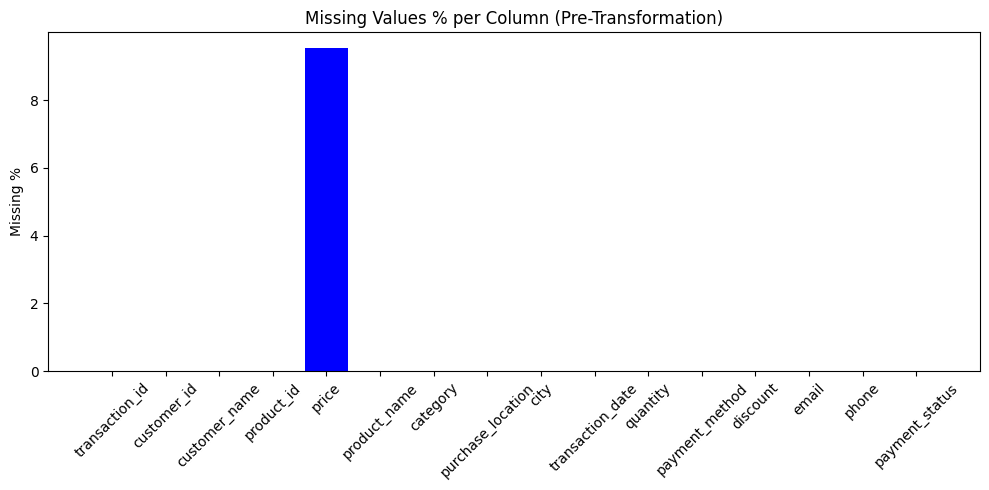

In [0]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(10, 5))
plt.bar(missing["column"], missing["missing_%"], color="blue")
plt.title("Missing Values % per Column (Pre-Transformation)")
plt.ylabel("Missing %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Missing Value Insights

- The **price** column is the only column containing missing values.
- The missing values can be resolved by joining the dataset with the **Product Details** table.

## Data Validation

The following columns will be validated:

- Price
- Product Name
- Product Category

To perform the validation, the **Retail_Data1** table will be joined with the **Products** table using an **INNER JOIN**. The joined dataset will be used to verify the accuracy and consistency of the product-related information.

In [0]:
# Loading the product details
product_details = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(f"{RAW_DATA_PATH}/product_details.csv")
)

product_details.display()

product_id,product_name,category,price
101,Laptop,Electronics,250000
102,Phone,Electronics,70000
103,Shirt,Clothing,1300
104,Shoes,Clothing,8000
105,TV,Electronics,45000
106,Sofa,Furniture,80000
107,Dining Table,Furniture,50000
108,Mixer Grinder,Home Appliances,15000
109,Refrigerator,Home Appliances,65000
110,Microwave,Home Appliances,45000


In [0]:
# Performing INNER JOIN on two tables (Retail data and Product details)
retail_alias = retail_data.alias("r")
product_alias = product_details.alias("p")

master_table = retail_alias.join(
    product_alias,
    on="product_id",
    how="inner"
)

In [0]:
master_table.display()

product_id,transaction_id,customer_id,customer_name,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status,product_name,category,price
108,1,642,Troy Mitchell,15000,Mixer grinder,Home Appliances,offline,Bangalore,2025-12-06,3,UPI,0.1,Troy60@gmail.com,8385276968,successful,Mixer Grinder,Home Appliances,15000
102,2,881,Sarah Guerrero,70000,Phone,ELEC,online,Bangalore,2025-07-21,5,Card,0.35,SarahGuerrero@yahoo.com,7147248911,successful,Phone,Electronics,70000
109,3,505,Samantha Hull,65000,Refrigerator,Home Appliances,offline,Chennai,2025-07-11,2,UPI,0.05,SamanthaHull@outlook.com,7415321565,successful,Refrigerator,Home Appliances,65000
106,4,794,Gerald Cooper,80000,sofa,FURN,offline,Chennai,2025-10-06,2,UPI,0.05,GeraldCooper@gmail.com,9739354201,successful,Sofa,Furniture,80000
108,5,864,Cameron Black,15000,Mixer grinder,home appliances,offline,Chennai,2025-12-12,1,Cash,0.05,CameronBlack@yahoo.com,9938169477,successful,Mixer Grinder,Home Appliances,15000
101,6,181,Maria Robinson,250000,laptop,Electronics,online,Delhi,2025-07-25,5,NetBanking,0.35,MariaRobinson@gmail.com,8794772717,successful,Laptop,Electronics,250000
101,6,181,Maria Robinson,250000,laptop,Electronics,online,Delhi,2025-07-25,5,NetBanking,0.35,MariaRobinson@gmail.com,8794772717,failed,Laptop,Electronics,250000
101,7,142,Charles Brown,250000,laptop,ELEC,online,Hyderabad,2026-03-03,2,UPI,0.05,Charles7@gmail.com,9980826322,successful,Laptop,Electronics,250000
102,8,457,Cathy Harris,70000,phone,Electronics,online,Hyderabad,02-19-2026,1,Card,0.05,Cathy90@gmail.com,8396657576,successful,Phone,Electronics,70000
110,9,749,Linda Lara,null,Microwave,home appliances,offline,Mumbai,2025-08-30,3,Card,0.3,LindaLara@outlook.com,7476164201,successful,Microwave,Home Appliances,45000


### Column Analysis

Let's now analyze the selected columns to identify any inconsistencies, mismatches, or data quality issues.

In [0]:
# Checking for price mismatch
from pyspark.sql.functions import col

master_table.filter(
    (col("r.price").isNotNull()) &
    (col("r.price") != col("p.price"))
).display()

product_id,transaction_id,customer_id,customer_name,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status,product_name,category,price


### Price Validation Insights

Based on the validation results, no price mismatches were identified between the **Retail_Data1** table and the **Products** table. This indicates that the price values are consistent across both datasets.

In [0]:
from pyspark.sql.functions import when

master_table.select(
    "transaction_id",
    "product_id",
    col("r.product_name").alias("retail_product_name"),
    col("p.product_name").alias("master_product_name"),
    when(
        col("r.product_name") != col("p.product_name"),
        "Mismatch"
    ).otherwise("Match").alias("name_check"),
    
    col("r.category").alias("retail_category"),
    col("p.category").alias("master_category"),
    when(
        col("r.category") != col("p.category"),
        "Mismatch"
    ).otherwise("Match").alias("category_check")
    
).filter(
    (col("name_check") == "Mismatch") |
    (col("category_check") == "Mismatch")
).display()

transaction_id,product_id,retail_product_name,master_product_name,name_check,retail_category,master_category,category_check
1,108,Mixer grinder,Mixer Grinder,Mismatch,Home Appliances,Home Appliances,Match
2,102,Phone,Phone,Match,ELEC,Electronics,Mismatch
4,106,sofa,Sofa,Mismatch,FURN,Furniture,Mismatch
5,108,Mixer grinder,Mixer Grinder,Mismatch,home appliances,Home Appliances,Mismatch
6,101,laptop,Laptop,Mismatch,Electronics,Electronics,Match
6,101,laptop,Laptop,Mismatch,Electronics,Electronics,Match
7,101,laptop,Laptop,Mismatch,ELEC,Electronics,Mismatch
8,102,phone,Phone,Mismatch,Electronics,Electronics,Match
9,110,Microwave,Microwave,Match,home appliances,Home Appliances,Mismatch
10,102,PHONE,Phone,Mismatch,electronics,Electronics,Mismatch


### Product Validation Insights

Mismatches were identified in the **Product Name** and **Product Category** columns.

To ensure data consistency and reduce duplication, the **Price**, **Product Name**, and **Product Category** columns can be excluded from the Retail Data table and sourced directly from the Products table when required.

In [0]:
print(master_table.count(), retail_data.count())

4243 4243



### Product Details Analysis Summary

No records were excluded during the join with the **Products** table (*Product Details*), indicating that every product referenced in **Retail_Data1** has a corresponding entry in the Products table.

Based on this analysis, the product-related information is consistent across both datasets. To improve normalization and reduce data redundancy, the **Price**, **Product Name**, and **Product Category** columns can be removed from **Retail_Data1** and sourced directly from the **Products** table when needed.

**This concludes the analysis of the Product Details data.**

## Duplicate Value Analysis

In [0]:
# Check duplicates per column
for col in retail_data.columns:
    print(f"Column: {col}, count: {retail_data.select(col).distinct().count()}")

Column: transaction_id, count: 4000
Column: customer_id, count: 979
Column: customer_name, count: 973
Column: product_id, count: 10
Column: price, count: 10
Column: product_name, count: 30
Column: category, count: 12
Column: purchase_location, count: 2
Column: city, count: 5
Column: transaction_date, count: 643
Column: quantity, count: 8
Column: payment_method, count: 4
Column: discount, count: 8
Column: email, count: 977
Column: phone, count: 979
Column: payment_status, count: 2



### Checking Duplicate Records Using Transaction ID

I found **243 records** with duplicate **Transaction IDs**. The next step is to verify whether the remaining column values are identical for records sharing the same Transaction ID.

In [0]:
from pyspark.sql.functions import count, col

# Getting duplicated Transaction_ids
duplicate_txns = (
    retail_data
    .groupBy("transaction_id")
    .count()
    .filter(col("count") > 1)
    .select("transaction_id")
)

duplicate_rows = retail_data.join(
    duplicate_txns,
    on="transaction_id",
    how="inner"
)

In [0]:
from pyspark.sql.functions import countDistinct

comparison_df = duplicate_rows.groupBy("transaction_id").agg(
    count("*").alias("row_count"),
    *[
        countDistinct(c).alias(f"{c}_distinct")
        for c in retail_data.columns
        if c != "transaction_id"
    ]
)

In [0]:
suspicious_txns = comparison_df.filter(
    " OR ".join(
        [
            f"{c}_distinct > 1"
            for c in retail_data.columns
            if c != "transaction_id"
        ]
    )
)

# suspicious_txns.display()

retail_data.join(
    suspicious_txns.select("transaction_id"),
    on="transaction_id",
    how="inner"
).display()

transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status
3749,185,Sarah Cohen,106,80000,sofa,furniture,offline,Mumbai,2026-01-05,3,Cash,0.05,SarahCohen@outlook.com,8825874728,failed
2580,623,Amanda George,101,250000,Laptop,ELEC,online,Chennai,2025-10-28,1,UPI,0.1,Amanda76@gmail.com,7955177000,failed
737,314,Paul Gonzales,108,15000,MIXER GRINDER,HOME,offline,Hyderabad,2025-09-04,4,Card,0.35,Paul48@gmail.com,6497754983,failed
1896,394,Jeffrey Johnson,104,8000,Shoes,clothing,offline,Mumbai,2025-03-10,4,Cash,0.3,JeffreyJohnson@yahoo.com,6876875341,failed
1975,132,Ronald Harrison,108,15000,MIXER GRINDER,home appliances,online,Delhi,10-24-2025,4,UPI,0.3,RonaldHarrison@yahoo.com,7238275967,failed
1265,500,Katelyn Garza,110,45000,microwave,HOME,online,Bangalore,2025-11-16,1,Card,0.35,KatelynGarza@yahoo.com,6200950083,failed
2655,569,Lindsay Levine,106,80000,sofa,furniture,online,Mumbai,2025-12-05,4,UPI,0.1,Lindsay32@gmail.com,6194157618,failed
2247,161,Christopher Davis,102,70000,phone,Electronics,offline,Mumbai,2025-06-03,3,NetBanking,0.1,ChristopherDavis@gmail.com,8222265633,failed
362,350,Gregory Knapp,109,65000,Refrigerator,home appliances,offline,Chennai,04-20-2025,2,NetBanking,0.4,GregoryKnapp@yahoo.com,9371443947,failed
3087,540,Amy Cruz,110,45000,Microwave,Home Appliances,offline,Delhi,2026-02-16,5,NetBanking,0.1,AmyCruz@gmail.com,7034946867,failed


In [0]:
retail_data.filter(
    col("transaction_id").isin(
        [3749, 737, 1896]
    )
).orderBy("transaction_id").show()

+--------------+-----------+---------------+----------+-----+-------------+---------+-----------------+---------+----------------+--------+--------------+--------+--------------------+----------+--------------+
|transaction_id|customer_id|  customer_name|product_id|price| product_name| category|purchase_location|     city|transaction_date|quantity|payment_method|discount|               email|     phone|payment_status|
+--------------+-----------+---------------+----------+-----+-------------+---------+-----------------+---------+----------------+--------+--------------+--------+--------------------+----------+--------------+
|           737|        314|  Paul Gonzales|       108|15000|MIXER GRINDER|     HOME|          offline|Hyderabad|      2025-09-04|       4|          Card|    0.35|    Paul48@gmail.com|6497754983|    successful|
|           737|        314|  Paul Gonzales|       108|15000|MIXER GRINDER|     HOME|          offline|Hyderabad|      2025-09-04|       4|          Card|  

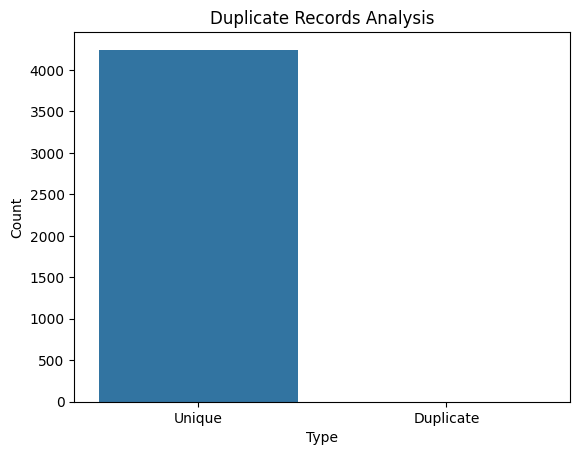

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

duplicate_count = df.duplicated().sum()

summary = pd.DataFrame({
    "Type":["Unique","Duplicate"],
    "Count":[
        len(df)-duplicate_count,
        duplicate_count
    ]
})

sns.barplot(data=summary,x="Type",y="Count")

plt.title("Duplicate Records Analysis")
plt.show()

In [0]:
duplicate_pct = (
    df.duplicated().sum()
    / len(df)
) * 100

print(f"Duplicate Percentage : {duplicate_pct:.2f}%")

Duplicate Percentage : 0.00%



### Insights from Duplicate Transaction ID Analysis

Further analysis revealed that the records sharing the same **Transaction ID** are not true duplicates. The rows differ in their **Payment Status**, which is either **Successful** or **Failed**.

Since these records represent different transaction outcomes, they should not be removed. Instead, the data can be separated into two tables based on the payment status:

- Transactions with a **Successful** payment status
- Transactions with a **Failed** payment status

This approach preserves all transaction records while enabling more efficient analysis of successful and failed payments.

### Checking for Duplicate Customer Records

Let's now examine the customer details for duplicate records.

In [0]:
retail_data.select(
    "customer_id",
    "customer_name"
).distinct().show()

+-----------+----------------+
|customer_id|   customer_name|
+-----------+----------------+
|        971|     Larry Ramos|
|        693|Joseph Maldonado|
|        380| Matthew Douglas|
|        280|   David Morales|
|        290|    Megan Carter|
|        761|     Larry Yates|
|        771|   Matthew Greer|
|        415|  Jackson Kaiser|
|        516|Brittany Roberts|
|        448|    Eileen Moore|
|        555|Christopher Cruz|
|        807|       Steven Li|
|        434|     Robert Sosa|
|         99|   Maria Mathews|
|        878|     Sarah Brown|
|        558|    Bryan Phelps|
|        167|  Madison Gentry|
|        271|     Jake Arnold|
|        839|     Erik Watson|
|        553|  Veronica Davis|
+-----------+----------------+
only showing top 20 rows


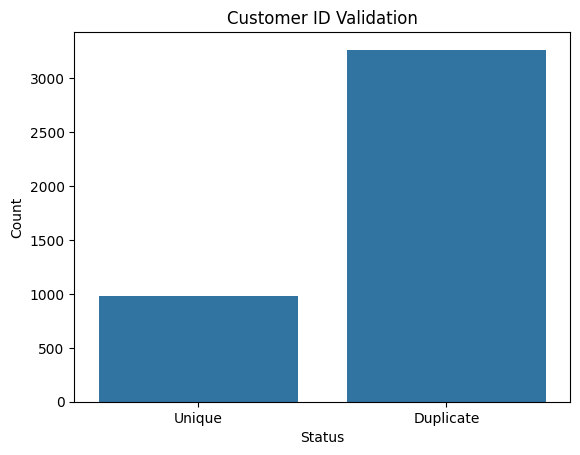

In [0]:
customer_duplicates = (
    df["customer_id"]
    .duplicated()
    .sum()
)

validation_df = pd.DataFrame({
    "Status":["Unique","Duplicate"],
    "Count":[
        len(df)-customer_duplicates,
        customer_duplicates
    ]
})

sns.barplot(
    data=validation_df,
    x="Status",
    y="Count"
)

plt.title("Customer ID Validation")
plt.show()

In [0]:
from pyspark.sql.functions import countDistinct, col

duplicate_names = (
    retail_data
    .groupBy("customer_name")
    .agg(
        countDistinct("customer_id").alias("id_count")
    )
    .filter(col("id_count") > 1)
)

# duplicate_names.display()

retail_data.join(
    duplicate_names.select("customer_name"),
    on="customer_name",
    how="inner"
).select(
    "customer_id",
    "customer_name"
).distinct().orderBy(
    "customer_name"
).show()

+-----------+---------------+
|customer_id|  customer_name|
+-----------+---------------+
|        321|   Chris Garcia|
|        846|   Chris Garcia|
|        242|     James Pham|
|        106|     James Pham|
|        932|Jessica Harrell|
|        375|Jessica Harrell|
|        889| Robert Carlson|
|        163| Robert Carlson|
|        878|    Sarah Brown|
|        453|    Sarah Brown|
|        419| William Taylor|
|        593| William Taylor|
+-----------+---------------+



### Customer Name Insights

There are **6 customer names** that are linked to more than one **Customer ID**.

### Validating Customer Email Addresses

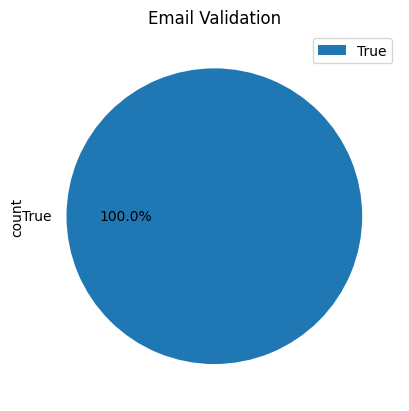

In [0]:
email_valid = df["email"].str.match(
    r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$',
    na=False
)

email_summary = email_valid.value_counts()

email_summary.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Email Validation")
plt.legend()
plt.show()

### Email Validation Insights

No invalid email addresses were identified during the validation process.

In [0]:
retail_data.select(
    ["email"]
).distinct().count()

# With this I can conclude that there's two emails which is asscociated to two different users

977

In [0]:
from pyspark.sql.functions import count, col

duplicate_emails = (
    retail_data
    .groupBy("email")
    .agg(countDistinct("customer_id").alias("customer_count"))
    .filter(col("customer_count") > 1)
    .select("email")
)

result = (
    retail_data
    .join(duplicate_emails, on="email", how="inner")
    .select(
        "customer_id",
        "customer_name",
        "email",
        "phone"
    )
)

result.distinct().show()

+-----------+--------------+--------------------+----------+
|customer_id| customer_name|               email|     phone|
+-----------+--------------+--------------------+----------+
|        593|William Taylor|WilliamTaylor@yah...|6951341384|
|        348|    James Nash|   James62@gmail.com|7753726437|
|        600|James Schaefer|   James62@gmail.com|9201434220|
|        419|William Taylor|WilliamTaylor@yah...|8507507668|
+-----------+--------------+--------------------+----------+




The records above indicate instances where the same **Email Address** is linked to multiple **Customer IDs**.

**This concludes the analysis of duplicate customer details.**

In [0]:
retail_data.limit(2).display()

transaction_id,customer_id,customer_name,product_id,price,product_name,category,purchase_location,city,transaction_date,quantity,payment_method,discount,email,phone,payment_status
1,642,Troy Mitchell,108,15000,Mixer grinder,Home Appliances,offline,Bangalore,2025-12-06,3,UPI,0.1,Troy60@gmail.com,8385276968,successful
2,881,Sarah Guerrero,102,70000,Phone,ELEC,online,Bangalore,2025-07-21,5,Card,0.35,SarahGuerrero@yahoo.com,7147248911,successful



### Duplicate Analysis Summary

No further duplicate values were found in the remaining tables.

The next step is to perform data validation on the following fields:

- Quantity
- Date
- Discount
- Phone Number

These checks will help identify any invalid, inconsistent, or out-of-range values within the dataset.

### Validating the Quantities

In [0]:
retail_data.select("quantity").distinct().show()

+--------+
|quantity|
+--------+
|      -1|
|       1|
|       3|
|       5|
|       4|
|      -2|
|       2|
|       0|
+--------+



In [0]:
validate_quantities = retail_data.withColumn(
    "valid_qauntity",
    when(
        col("quantity") < 0, "INVALID"
    ).otherwise("VALID")
)

validate_quantities.select(["quantity", "valid_qauntity"]).distinct().show()

+--------+--------------+
|quantity|valid_qauntity|
+--------+--------------+
|      -2|       INVALID|
|       1|         VALID|
|      -1|       INVALID|
|       3|         VALID|
|       0|         VALID|
|       4|         VALID|
|       5|         VALID|
|       2|         VALID|
+--------+--------------+



In [0]:
validate_quantities.groupBy("valid_qauntity").count().show()

+--------------+-----+
|valid_qauntity|count|
+--------------+-----+
|         VALID| 4209|
|       INVALID|   34|
+--------------+-----+




### Quantity Validation Insights

Based on the analysis:

- **34 records** contain invalid quantity values.
- **4,209 records** contain valid quantity values.

To support downstream analysis and reporting, quantity records will be labeled as **Valid** or **Invalid** rather than being removed from the dataset.

**This concludes the quantity data validation process.**

### Validating the dates

In [0]:
print("Count is: ",retail_data.select("transaction_date").distinct().count())
retail_data.select("transaction_date").distinct().show(10)

Count is:  643
+----------------+
|transaction_date|
+----------------+
|      2026-02-01|
|      2025-06-03|
|      06-21-2025|
|      10-19-2025|
|      2026-02-27|
|      2025-08-17|
|      2025-09-14|
|      2026-07-04|
|      2025-04-05|
|      2026-04-15|
+----------------+
only showing top 10 rows


In [0]:
retail_data.printSchema()

root
 |-- transaction_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- price: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- purchase_location: string (nullable = true)
 |-- city: string (nullable = true)
 |-- transaction_date: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- discount: double (nullable = true)
 |-- email: string (nullable = true)
 |-- phone: long (nullable = true)
 |-- payment_status: string (nullable = true)



In [0]:
from pyspark.sql.functions import when, col

date_check_df = retail_data.withColumn(
    "date_format",
    when(
        col("transaction_date").rlike(r"^\d{4}-\d{2}-\d{2}$"),
        "yyyy-MM-dd"
    ).when(
        col("transaction_date").rlike(r"^\d{2}-\d{2}-\d{4}$"),
        "dd-MM-yyyy or MM-dd-yyyy"
    )
)

date_check_df.select(["transaction_date","date_format"]).distinct().show(10)

+----------------+--------------------+
|transaction_date|         date_format|
+----------------+--------------------+
|      2025-12-06|          yyyy-MM-dd|
|      2025-10-09|          yyyy-MM-dd|
|      03-26-2026|dd-MM-yyyy or MM-...|
|      02-15-2026|dd-MM-yyyy or MM-...|
|      04-21-2025|dd-MM-yyyy or MM-...|
|      06-20-2025|dd-MM-yyyy or MM-...|
|      2025-05-09|          yyyy-MM-dd|
|      2025-09-14|          yyyy-MM-dd|
|      2025-07-03|          yyyy-MM-dd|
|      2025-06-27|          yyyy-MM-dd|
+----------------+--------------------+
only showing top 10 rows


In [0]:
date_check_df.select("date_format").distinct().count()

2

In [0]:
retail_data.select("transaction_date").distinct().count()

643

In [0]:
from pyspark.sql.functions import when, col, split

date_check_df = date_check_df.withColumn(
    "date_order",
    when(
        (col("date_format") == "dd-MM-yyyy or MM-dd-yyyy"),
        when(
            split(col("transaction_date"), "-")[0].cast("int") > 12,
            "dd-MM-yyyy"
        ).when(
            split(col("transaction_date"), "-")[1].cast("int") > 12 ,
            "MM-dd-yyyy"
        )
    ).otherwise(
        col("date_format")
    )
)

date_check_df.select(["transaction_date","date_format", "date_order"]).distinct().show(10)

+----------------+--------------------+----------+
|transaction_date|         date_format|date_order|
+----------------+--------------------+----------+
|      2025-12-22|          yyyy-MM-dd|yyyy-MM-dd|
|      11-27-2025|dd-MM-yyyy or MM-...|MM-dd-yyyy|
|      2026-11-01|          yyyy-MM-dd|yyyy-MM-dd|
|      12-24-2025|dd-MM-yyyy or MM-...|MM-dd-yyyy|
|      08-15-2025|dd-MM-yyyy or MM-...|MM-dd-yyyy|
|      2025-10-28|          yyyy-MM-dd|yyyy-MM-dd|
|      2025-11-24|          yyyy-MM-dd|yyyy-MM-dd|
|      01-24-2026|dd-MM-yyyy or MM-...|MM-dd-yyyy|
|      2025-09-21|          yyyy-MM-dd|yyyy-MM-dd|
|      2026-01-08|          yyyy-MM-dd|yyyy-MM-dd|
+----------------+--------------------+----------+
only showing top 10 rows


In [0]:
date_check_df.groupBy("date_order").count().show()

+----------+-----+
|date_order|count|
+----------+-----+
|yyyy-MM-dd| 3363|
|MM-dd-yyyy|  880|
+----------+-----+



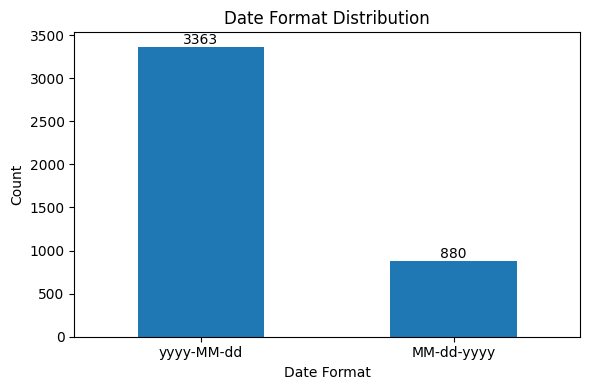

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

date_check_pdf = date_check_df.toPandas()

ax = date_check_pdf["date_order"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Date Format Distribution")
plt.xlabel("Date Format")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Date Validation Insights

Based on the validation results:

- No missing values were found in the **Date** column.
- The column contains two different date formats:
  - **yyyy-MM-dd**
  - **MM-dd-yyyy**
- The current data type of the column is **String**.

To ensure consistency and enable date-based analysis, the date values should first be standardized into a single format and then converted to the **Date** data type. We will convert the **MM-dd-yyyy** to **yyyy-MM-dd** during transformation as the number of rows is less compared to the other.

**This concludes the date validation analysis.**

### Validating the Phone numbers

In [0]:
retail_data.printSchema()

root
 |-- transaction_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- price: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- purchase_location: string (nullable = true)
 |-- city: string (nullable = true)
 |-- transaction_date: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- discount: double (nullable = true)
 |-- email: string (nullable = true)
 |-- phone: long (nullable = true)
 |-- payment_status: string (nullable = true)




### Phone Number Validation

The **Phone Number** column is currently stored as a **Long** data type and should be cast to **String** before performing validation checks.

The following validations will be performed:

- Verify that each phone number contains exactly **10 digits**.
- Ensure that phone numbers do not contain any **leading zeros**.
- Identify and flag any records that do not satisfy these conditions.

**This validation will help ensure the accuracy and consistency of customer contact information.**

In [0]:
# Creating a new column which will be used for phone number validation
retail_data = retail_data.withColumn(
    "phone_str",
    col("phone").cast("string")
)

In [0]:
retail_data.select(
    "phone",
    "phone_str"
).distinct().show(10)

+----------+----------+
|     phone| phone_str|
+----------+----------+
|7562005843|7562005843|
|6003830167|6003830167|
|6565238386|6565238386|
|8013465736|8013465736|
|8932172521|8932172521|
|7070665200|7070665200|
|9277458368|9277458368|
|9917575841|9917575841|
|9657619972|9657619972|
|6194157618|6194157618|
+----------+----------+
only showing top 10 rows


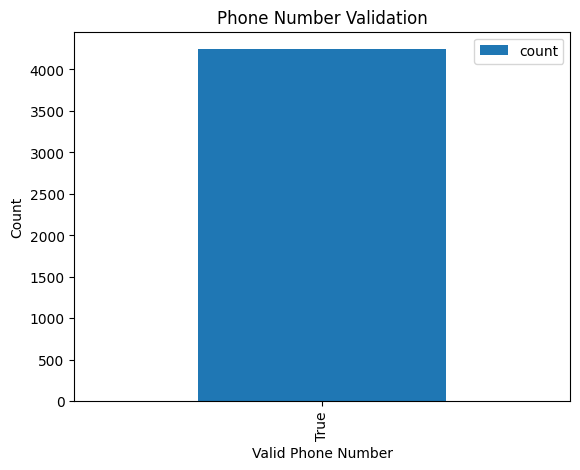

In [0]:
phone_valid = (
    df["phone"]
    .astype(str)
    .str.match(r'^\d{10}$')
)

phone_valid.value_counts().plot(
    kind='bar'
)

plt.title("Phone Number Validation")
plt.xlabel("Valid Phone Number")
plt.ylabel("Count")
plt.legend()
plt.show()

In [0]:
from pyspark.sql.functions import col

retail_data.filter(
    col("phone_str").isNull()
).select(["phone","phone_str"]).show()

+-----+---------+
|phone|phone_str|
+-----+---------+
+-----+---------+




### Phone Number Conversion Insights

No NULL values were found in the **phone_str** column after the data type conversion. This indicates that all phone number values were successfully converted from **Long** to **String** without any data loss.

In [0]:
from pyspark.sql.functions import length

retail_data.withColumn(
    "phone_length",
    length(col("phone_str"))
).groupBy(
    "phone_length"
).count().show()

+------------+-----+
|phone_length|count|
+------------+-----+
|          10| 4243|
+------------+-----+



In [0]:
retail_data.count()

4243


### Phone Number Validation Insights

The number of records with a valid **10-digit phone length** matches the total row count, indicating that all phone numbers are valid.

Furthermore, as the source data is stored as a numeric data type, leading zeros are not possible.

**This concludes the phone number validation analysis.**

**Validating Discount column**

In [0]:
retail_data.select("discount").distinct().show()

+--------+
|discount|
+--------+
|     0.2|
|    0.05|
|     0.1|
|    0.35|
|     0.4|
|    0.15|
|    0.25|
|     0.3|
+--------+




### Discount Validation Insights

Based on the distinct discount values observed in the dataset, the discount data appears to be valid and consistent.

No anomalies or unexpected values were identified, and therefore no additional validation checks are required.

**This concludes the discount validation analysis.**

### Checking the remaining columns

In [0]:
retail_data.select("payment_method").distinct().show()

+--------------+
|payment_method|
+--------------+
|    NetBanking|
|          Card|
|          Cash|
|           UPI|
+--------------+



In [0]:
retail_data.select("payment_status").distinct().show()

+--------------+
|payment_status|
+--------------+
|        failed|
|    successful|
+--------------+



In [0]:
retail_data.select("city").distinct().show()

+---------+
|     city|
+---------+
|Bangalore|
|  Chennai|
|   Mumbai|
|    Delhi|
|Hyderabad|
+---------+



In [0]:
retail_data.select("purchase_location").distinct().show()

+-----------------+
|purchase_location|
+-----------------+
|           online|
|          offline|
+-----------------+




### Data Conversion Summary

No further data type conversions or transformations are required for these tables.

### Data Privacy

Both **Email ID** and **Phone Number** are considered **Personally Identifiable Information (PII)** and must be protected through data masking or hashing.

* A separate **Customer table** will be created to store customer-related information, where masking or hashing can be applied efficiently.
* This approach reduces processing overhead on the main `retail_data` table and improves data organization.
* Since email addresses and phone numbers are not required for business analysis, securing these fields helps maintain privacy without impacting analytical outcomes.


In [0]:
from pyspark.sql.functions import (
    col,
    concat,
    lit,
    substring,
    instr,
    regexp_extract
)

customer_df = retail_data.select(
    "customer_id",
    "customer_name",

    # Original Email, 
    "email",

    # Masked Email
    concat(
        substring(col("email"), 1, 2),
        lit("******"),
        regexp_extract(col("email"), "(@.*)", 1)
    ).alias("email_masked"),

    # Original Phone, 
    "phone",

    # Masked Phone
    concat(
        substring(col("phone").cast("string"), 1, 2),
        lit("******"),
        substring(col("phone").cast("string"), 9, 2)
    ).alias("phone_masked")
)

In [0]:
customer_df.show(10)

+-----------+--------------+--------------------+--------------------+----------+------------+
|customer_id| customer_name|               email|        email_masked|     phone|phone_masked|
+-----------+--------------+--------------------+--------------------+----------+------------+
|        642| Troy Mitchell|    Troy60@gmail.com|  Tr******@gmail.com|8385276968|  83******68|
|        881|Sarah Guerrero|SarahGuerrero@yah...|  Sa******@yahoo.com|7147248911|  71******11|
|        505| Samantha Hull|SamanthaHull@outl...|Sa******@outlook.com|7415321565|  74******65|
|        794| Gerald Cooper|GeraldCooper@gmai...|  Ge******@gmail.com|9739354201|  97******01|
|        864| Cameron Black|CameronBlack@yaho...|  Ca******@yahoo.com|9938169477|  99******77|
|        181|Maria Robinson|MariaRobinson@gma...|  Ma******@gmail.com|8794772717|  87******17|
|        181|Maria Robinson|MariaRobinson@gma...|  Ma******@gmail.com|8794772717|  87******17|
|        142| Charles Brown|  Charles7@gmail.com| 

**Both the original and masked values will be retained in the dataset. However, only the masked values will be used for business reporting and analytical purposes.**


%md

# Final Conclusion

The Exploratory Data Analysis (EDA) and data quality assessment of the **Retail_Data1** dataset have been successfully completed.

### Key Findings

- Missing values were identified only in the **Price** column and can be resolved through a join with the **Products** table.
- Product-related attributes (**Price**, **Product Name**, and **Product Category**) were validated against the Products table and found to be consistent.
- No records were excluded during the product validation process, confirming referential integrity between the datasets.
- Duplicate **Transaction IDs** were investigated and determined to represent different transaction outcomes (**Successful** and **Failed**) rather than true duplicate records.
- Customer data was analyzed for duplication, revealing instances where the same customer name or email address was associated with multiple customer IDs.
- Quantity, Date, Discount, and Phone Number fields were validated to identify inconsistencies and improve data quality.
- Date values were found in multiple formats and require standardization before conversion to the Date data type.
- Phone numbers were successfully validated and confirmed to contain valid 10-digit values.
- Discount values were validated and found to be consistent across the dataset.

### Data Preparation Decisions

- Product-related columns can be removed from the retail transaction table and sourced directly from the Products table to reduce redundancy and improve normalization.
- Quantity records will be labeled as **Valid** or **Invalid** instead of being removed.
- Sensitive customer information will be masked while retaining original values for governance and operational purposes.
- Only masked values will be exposed for business reporting and analytical use.

### Outcome

The dataset has been thoroughly analyzed, validated, and prepared for downstream data engineering, reporting, dashboarding, and business analytics activities. The identified data quality issues have been documented, and appropriate remediation strategies have been defined to ensure reliable and consistent business insights.